In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.metrics import classification_report, confusion_matrix

In [5]:
# 2. Load the Data
df_10 = pd.read_csv('../data/Train_Test_Windows_dataset/Train_Test_Windows_10.csv')
df_7 = pd.read_csv('../data/Train_Test_Windows_dataset/Train_Test_Windows_7.csv')

In [155]:
print("Windows 10 shape:", df_10.shape)
print("Windows 7 shape:", df_7.shape)

Windows 10 shape: (21104, 126)
Windows 7 shape: (15980, 134)


In [156]:
df_10.head()

,Processor_DPC_Rate,Processor_pct_ Idle_Time,Processor_pct_ C3_Time,Processor_pct_ Interrupt_Time,Processor_pct_ C2_Time,Processor_pct_ User_Time,Processor_pct_ C1_Time,Processor_pct_ Processor_Time,Processor_C1_ransitions_sec,Processor_pct_ DPC_Time,...,LogicalDisk(_Total) Avg Disk Write Queue Length,LogicalDisk(_Total) Avg Disk Queue Length,LogicalDisk(_Total) pct_ Disk Read Time,LogicalDisk(_Total) Disk Write Bytes sec,LogicalDisk(_Total) Disk Transfers sec,LogicalDisk(_Total) Avg Disk Bytes Transfer,LogicalDisk(_Total) pct_ Disk Write Time,LogicalDisk(_Total) Avg Disk sec Transfer,label,type
0,0,49.07244938,0,0.779671928,0,21.830814,49.07244938,45.5788994,405.2109934,0.155934386,...,0.035543669,0.035727836,0.006138575,980725.4671,61.12065428,16125.91191,1.184788963,0.000584015,1,dos
1,17,0,0,1.170522789,0,38.15904291,0,100,0,2.41908043,...,0.071868506,0.113428645,1.38968492,695437.4911,56.84042385,17923.5993,2.403132421,0.001995776,1,dos
2,11,0,0,0.546510062,0,65.1127703,0,100,0,0.312291464,...,0.010271601,0.023255341,0.432790999,691341.4197,9.388015072,86462.6383,0.342387367,0.002475624,1,dos
3,0,0,0,0.78081667,0,68.94611198,0,100,0,1.015061671,...,0.062088903,0.070302274,0.273779061,1039903.208,81.89439351,13206.97436,2.069629418,0.000858868,1,dos
4,0,0,0,0.468739969,0,66.0142123,0,100,0,0.156246656,...,0.100304043,0.123923448,0.787313151,2498188.869,190.1717481,15214.36803,3.34346845,0.000651557,1,dos


In [157]:
df_7.head()

,Processor(_Total) DPC Rate,Processor(_Total) pct_ Idle Time,Processor(_Total) pct_ C3 Time,Processor(_Total) pct_ Interrupt Time,Processor(_Total) pct_ C2 Time,Processor(_Total) pct_ User Time,Processor(_Total) pct_ C1 Time,Processor(_Total) pct_ Processor Time,Processor(_Total) C1 Transitions sec,Processor(_Total) pct_ DPC Time,...,Memory Available MBytes,Memory Modified Page List Bytes,Memory Cache Faults sec,Memory Committed Bytes,Memory System Driver Total Bytes,Memory Pages Input sec,Memory Pool Paged Resident Bytes,Memory Write Copies sec,label,type
0,0,85.52083333,0,0,0,13.125,86.66666667,14.47916667,59.35463175,0.520833333,...,251,12070912,0.466834182,1943322624,5849088,1.200430755,27090944,0,1,ddos
1,0,73.85416667,0,0,0,24.6875,73.33333333,26.14583333,52.19953716,0.208333333,...,267,12025856,0.59999468,1933844480,5849088,7.599932614,27181056,0,1,ddos
2,0,85.83333333,0,0,0,13.125,86.66666667,14.16666667,59.06549008,0.208333333,...,256,11960320,0.399992032,1937002496,5849088,0,27185152,0,1,ddos
3,0,88.54166667,0,0,0,10.72916667,86.66666667,11.45833333,62.00056255,0.104166667,...,262,12066816,0.400003629,1930117120,5849088,0,27185152,0,1,ddos
4,0,83.54166667,0,0.104166667,0,14.79166667,80,16.45833333,76.73258954,0.3125,...,240,118784,4.666621432,1960501248,5849088,74.06594872,27201536,0,1,ddos


In [158]:
df_10.tail()

,Processor_DPC_Rate,Processor_pct_ Idle_Time,Processor_pct_ C3_Time,Processor_pct_ Interrupt_Time,Processor_pct_ C2_Time,Processor_pct_ User_Time,Processor_pct_ C1_Time,Processor_pct_ Processor_Time,Processor_C1_ransitions_sec,Processor_pct_ DPC_Time,...,LogicalDisk(_Total) Avg Disk Write Queue Length,LogicalDisk(_Total) Avg Disk Queue Length,LogicalDisk(_Total) pct_ Disk Read Time,LogicalDisk(_Total) Disk Write Bytes sec,LogicalDisk(_Total) Disk Transfers sec,LogicalDisk(_Total) Avg Disk Bytes Transfer,LogicalDisk(_Total) pct_ Disk Write Time,LogicalDisk(_Total) Avg Disk sec Transfer,label,type
21099,0,48.02591125,0,0.234004125,0,43.52476716,48.02591125,50.0791201,147.5671891,0.15600275,...,0.001008811,0.001143588,0.004491881,11859.68944,1.297952273,14493.53846,0.033627703,0.000881077,1,mitm
21100,0,63.66271811,0,0.078245719,0,30.75056759,63.66271811,34.35184171,165.8555585,0,...,0.001484681,0.001533736,0.001635523,29946.94375,4.30663588,8477.767442,0.049489353,0.000356133,1,mitm
21101,1,82.34150729,0,0,0,15.21082955,82.34150729,16.30143536,189.6071196,0,...,0.000447637,0.000447637,0,15182.94736,1.497686568,10137.6,0.014921902,0.000298887,1,mitm
21102,0,38.79268029,0,0.156245925,0,23.04627395,38.79268029,59.84479725,172.9953291,0.156245925,...,0.000617754,0.000690462,0.002422937,12697.25717,0.899975701,17749.33333,0.020592463,0.0007672,1,mitm
21103,0,78.30895202,0,0,0,16.84863458,78.30895202,19.03295048,375.7142089,0.078002938,...,0.001771628,0.04218986,1.347274731,74022.18904,78.5774867,30962.01271,0.059054589,0.000536924,1,mitm


In [159]:
df_7.tail()

,Processor(_Total) DPC Rate,Processor(_Total) pct_ Idle Time,Processor(_Total) pct_ C3 Time,Processor(_Total) pct_ Interrupt Time,Processor(_Total) pct_ C2 Time,Processor(_Total) pct_ User Time,Processor(_Total) pct_ C1 Time,Processor(_Total) pct_ Processor Time,Processor(_Total) C1 Transitions sec,Processor(_Total) pct_ DPC Time,...,Memory Available MBytes,Memory Modified Page List Bytes,Memory Cache Faults sec,Memory Committed Bytes,Memory System Driver Total Bytes,Memory Pages Input sec,Memory Pool Paged Resident Bytes,Memory Write Copies sec,label,type
15975,0,99.375,0,0.104166667,0,0.208333333,93.33333333,0.625,69.39599169,0,...,512,28692480,0,989159424,5832704,0,33837056,0,1,scanning
15976,0,98.95833333,0,0,0,0.3125,93.33333333,1.041666667,69.06618505,0.104166667,...,510,28655616,0,991559680,5832704,0,33837056,0,1,scanning
15977,0,99.58333333,0,0,0,0.208333333,100,0.416666667,69.53555198,0.104166667,...,510,28504064,0,990556160,5832704,0,33837056,0,1,scanning
15978,0,99.16666667,0,0.104166667,0,0.208333333,100,0.833333333,69.13535808,0.104166667,...,509,27869184,0,991739904,5832704,0,33894400,0,1,scanning
15979,0,99.47916667,0,0,0,0.208333333,93.33333333,0.520833333,71.40151276,0,...,509,27840512,0,991444992,5832704,0,33894400,0,1,scanning


In [160]:
df_10.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21104 entries, 0 to 21103
Columns: 126 entries, Processor_DPC_Rate to type
dtypes: float64(5), int64(51), object(70)
memory usage: 20.3+ MB


In [161]:
df_7.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15980 entries, 0 to 15979
Columns: 134 entries, Processor(_Total) DPC Rate to type
dtypes: float64(1), int64(65), object(68)
memory usage: 16.3+ MB


In [162]:
# 3. Inspect Target
print(df_10['type'].value_counts())

type
normal       10000
ddos          4608
password      3628
xss           1269
injection      612
dos            525
scanning       447
mitm            15
Name: count, dtype: int64


In [163]:
print(df_7['type'].value_counts())

type
normal        10000
ddos           2134
backdoor       1779
injection       998
password        757
scanning        226
ransomware       82
xss               4
Name: count, dtype: int64


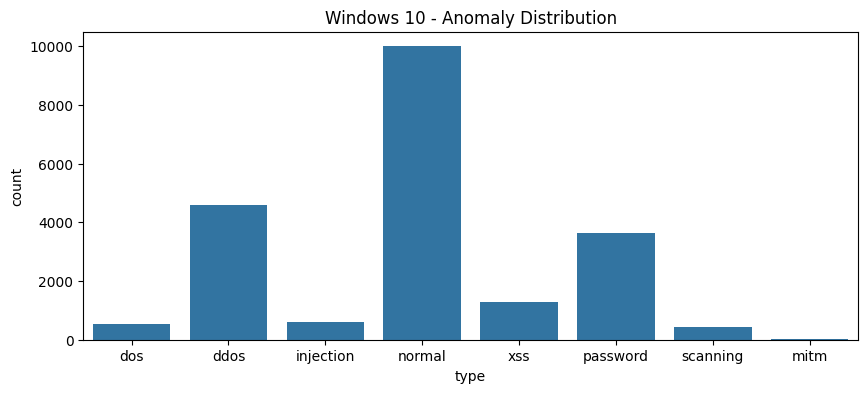

In [164]:

# Visualize class balance
plt.figure(figsize=(10, 4))
sns.countplot(data=df_10, x='type')
plt.title("Windows 10 - Anomaly Distribution")
plt.show()

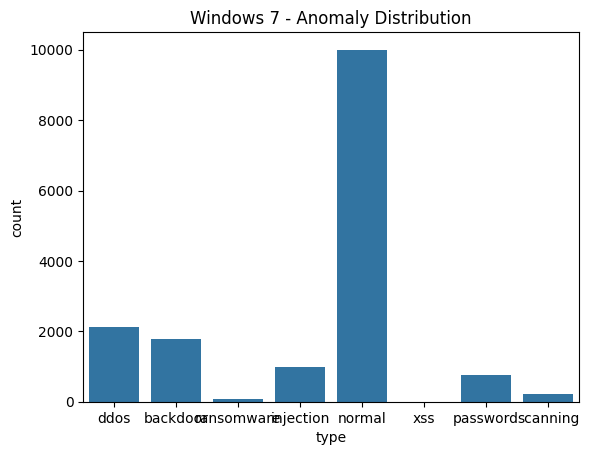

In [165]:

sns.countplot(data=df_7, x='type')
plt.title("Windows 7 - Anomaly Distribution")
plt.show()


In [166]:
df_7.dtypes

,0
Processor(_Total) DPC Rate,int64
Processor(_Total) pct_ Idle Time,object
Processor(_Total) pct_ C3 Time,object
Processor(_Total) pct_ Interrupt Time,object
Processor(_Total) pct_ C2 Time,object
...,...
Memory Pages Input sec,object
Memory Pool Paged Resident Bytes,int64
Memory Write Copies sec,object
label,int64


In [167]:
for col in df_7.columns:
  if df_7[col].dtype == 'object':
      print(df_7[col].unique())

['85.52083333' '73.85416667' '85.83333333' ... '42.21525601' '21.875'
 '5.109156064']
['0' ' ']
['0' '0.104166667' '0.208333333' '0.416666667' '0.104058273' '0.207900208'
 '0.052083333' '0.052137643' ' ' '0.521376434' '1.197682751' '1.092967275'
 '0.46875' '0.15625' '0.104207372' '0.260416667' '0.3125' '0.677083333'
 '0.78125' '0.364583333' '1.041666667' '0.520833333' '0.572916667'
 '0.052029136' '0.208550574' '0.104275287' '0.103950104' '0.208116545'
 '0.313152401' '0.208768267' '0.833333333' '0.102249489' '0.106157113'
 '0.100704935' '0.9375' '0.729166667' '0.625' '1.458333333' '0.728407908'
 '0.938477581' '0.616649538' '1.261829653' '1.25' '2.405857741'
 '1.354166667' '1.145833333' '2.291666667' '0.51975052' '1.456815817'
 '0.518134715' '0.418848168' '1.770833333' '0.31152648' '1.668404588'
 '0.417536534' '0.723140496' '1.573976915' '1.042752868' '0.205338809'
 '0.317124736' '0.727650728' '1.043841336' '0.935550936' '1.14822547'
 '1.875' '0.715015322' '0.425079702' '0.312174818' '0.

In [168]:
import joblib

def preprocess_data(df, scaler_path='scaler.pkl', label_encoder_path='label_encoder.pkl'):
    df = df.copy()
    df.drop('label',axis=1,inplace=True)

    # Separate target
    y = df['type']
    df.drop(columns=['type'],axis=1,inplace=True)

    # Encode categorical features
 # Note: not saved here, only target encoder saved


    for col in df.columns:
        if df[col].dtype == 'object':  # only convert object columns
            df[col] = pd.to_numeric(df[col], errors='coerce').astype(float)
    df.fillna(0.0,inplace=True)
    # Normalize features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df)
    joblib.dump(scaler, scaler_path)

    # Encode target
    label_encoder = LabelEncoder()
    y_enc = label_encoder.fit_transform(y)
    joblib.dump(label_encoder, label_encoder_path)

    return X_scaled, y_enc


In [169]:
X10, y10 = preprocess_data(df_10,"df_10_scaler.pkl","df_10_encoder.pkl")
X7, y7 = preprocess_data(df_7,"df_7_scaler.pkl","df_7_encoder.pkl")

In [170]:
X10

array([[-0.31266966, -0.9774071 ,  0.        , ..., -0.19710637,
        -0.10685042, -0.13401993],
       [ 0.70006784, -3.40211231,  0.        , ..., -0.16535852,
        -0.01296386,  1.10179265],
       [ 0.34263108, -3.40211231,  0.        , ...,  1.04506723,
        -0.17176659,  1.52183698],
       ...,
       [-0.25309687,  0.66644112,  0.        , ..., -0.30286225,
        -0.19700135, -0.3836123 ],
       [-0.31266966, -1.48533792,  0.        , ..., -0.16843612,
        -0.19656437,  0.02633464],
       [-0.31266966,  0.46718964,  0.        , ...,  0.06490487,
        -0.19360045, -0.17524196]])

In [171]:
X_train10, X_test10, y_train10, y_test10 = train_test_split(X10, y10, test_size=0.2, stratify=y10)
X_train7, X_test7, y_train7, y_test7 = train_test_split(X7, y7, test_size=0.2, stratify=y7)

In [172]:
from imblearn.over_sampling import SMOTE
from collections import Counter
import pandas as pd


In [173]:
print("Original class distribution:", Counter(y_train10))
print("Original class distribution:", Counter(y_train7))

Original class distribution: Counter({np.int64(4): 8000, np.int64(0): 3686, np.int64(5): 2902, np.int64(7): 1015, np.int64(2): 490, np.int64(1): 420, np.int64(6): 358, np.int64(3): 12})
Original class distribution: Counter({np.int64(3): 8000, np.int64(1): 1707, np.int64(0): 1423, np.int64(2): 798, np.int64(4): 606, np.int64(6): 181, np.int64(5): 66, np.int64(7): 3})


In [174]:
smote10 = SMOTE(random_state=42)
smote7 = SMOTE(k_neighbors=2, random_state=42)


In [175]:
# Apply SMOTE to feature and target arrays
X_train10, y_train10 = smote10.fit_resample(X_train10, y_train10)
X_train7, y_train7 = smote7.fit_resample(X_train7, y_train7)

In [176]:
def build_model(input_shape, num_classes):

    print(num_classes)
    inputs = layers.Input(shape=(input_shape,))
    x = layers.Dense(256, activation='relu')(inputs)
    x = layers.Dropout(0.4)(x, training=True)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x, training=True)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inputs, outputs)


In [177]:
from sklearn.utils.class_weight import compute_class_weight

def train_model(X_train, y_train, X_val, y_val):
    num_classes = len(np.unique(y_train))

    # Ensure labels are integers 0...num_classes-1
    y_train = y_train.astype(int)
    y_val = y_val.astype(int)

    model = build_model(X_train.shape[1], num_classes)

    # 🔁 Correct loss function
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    # ⚖️ Class weights to handle imbalance
    class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
    class_weight_dict = dict(enumerate(class_weights))

    early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    history = model.fit(X_train, y_train,
                        epochs=20, batch_size=64,
                        validation_data=(X_val, y_val),
                        class_weight=class_weight_dict,
                        callbacks=[early_stop])

    return model, history


In [178]:
model_win10, history10 = train_model(X_train10, y_train10, X_test10, y_test10)
model_win7, history7 = train_model(X_train7, y_train7, X_test7, y_test7)


8
Epoch 1/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9467 - loss: 0.1946 - val_accuracy: 0.9998 - val_loss: 0.0013
Epoch 2/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9997 - loss: 0.0017 - val_accuracy: 0.9995 - val_loss: 0.0016
Epoch 3/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9996 - loss: 0.0018 - val_accuracy: 0.9995 - val_loss: 0.0042
Epoch 4/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9997 - loss: 8.2923e-04 - val_accuracy: 0.9993 - val_loss: 0.0069
Epoch 5/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9997 - loss: 0.0012 - val_accuracy: 0.9995 - val_loss: 0.0032
Epoch 6/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9998 - loss: 8.3905e-04 - val_accuracy: 0.9995 - val_loss: 0.0053
8
Epoch 1/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9388 - loss: 0.2183 - val_accuracy: 0.9812 - val_loss: 0.0622
Epoch 2/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.9967 - los

In [179]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def evaluate_model(model, X_test, y_test):
    # Get predicted class indices
    preds_prob = model.predict(X_test)
    preds = np.argmax(preds_prob, axis=1)

    print("Classification Report:\n")
    print(classification_report(y_test, preds))

    # Confusion Matrix
    cm = confusion_matrix(y_test, preds)
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title('Confusion Matrix')
    plt.show()


=== Evaluation on Windows 10 Dataset ===
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       922
           1       0.99      1.00      1.00       105
           2       1.00      1.00      1.00       122
           3       1.00      1.00      1.00         3
           4       1.00      1.00      1.00      2000
           5       1.00      1.00      1.00       726
           6       1.00      0.99      0.99        89
           7       1.00      1.00      1.00       254

    accuracy                           1.00      4221
   macro avg       1.00      1.00      1.00      4221
weighted avg       1.00      1.00      1.00      4221



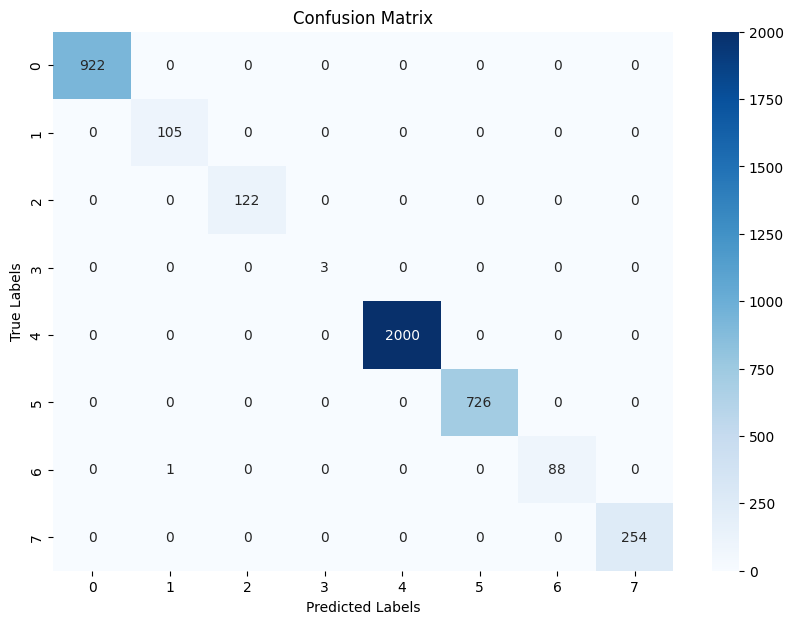

In [180]:
print("=== Evaluation on Windows 10 Dataset ===")
evaluate_model(model_win10, X_test10, y_test10)

=== Evaluation on Windows 7 Dataset ===
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       356
           1       1.00      1.00      1.00       427
           2       1.00      0.99      1.00       200
           3       1.00      1.00      1.00      2000
           4       0.99      1.00      1.00       151
           5       1.00      1.00      1.00        16
           6       1.00      1.00      1.00        45
           7       0.00      0.00      0.00         1

    accuracy                           1.00      3196
   macro avg       0.87      0.87      0.87      3196
weighted avg       1.00      1.00      1.00      3196



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


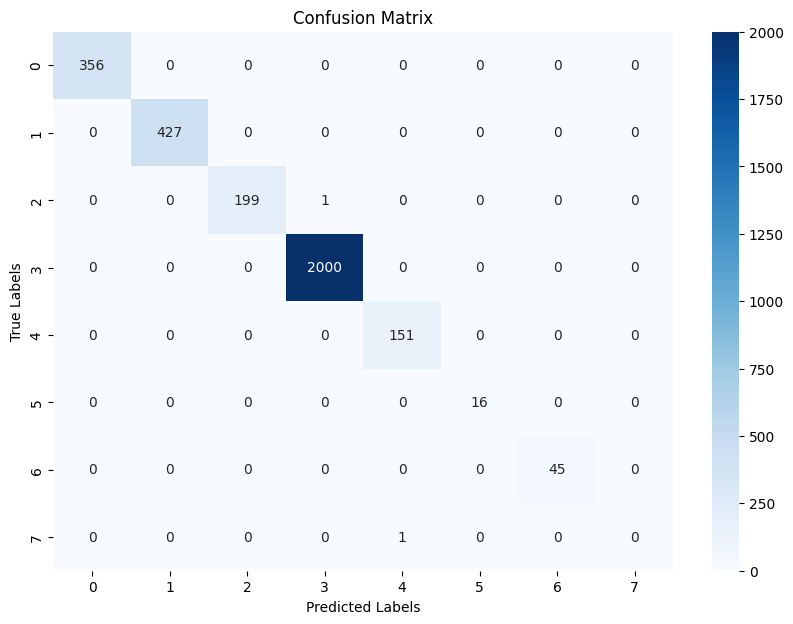

In [181]:
print("=== Evaluation on Windows 7 Dataset ===")
evaluate_model(model_win7, X_test7, y_test7)

In [182]:
model_win10.save('windows_10_model.h5')
model_win7.save('windows_7_model.h5')

In [190]:
import joblib
import numpy as np
import pandas as pd
from tensorflow.keras.models import load_model
from sklearn.preprocessing import LabelEncoder

def predict_anomaly(data, os_type, model_path_base='windows', scaler_path_base='df', encoder_path_base='df'):
    """
    Predicts the anomaly type for a single data point.

    Args:
        data (pd.DataFrame, dict, or list): The input data point as a DataFrame, dictionary, or list of values.
        os_type (str): The operating system type ('10' for Windows 10, '7' for Windows 7).
        model_path_base (str): The base path for the saved model files.
        scaler_path_base (str): The base path for the saved scaler files.
        encoder_path_base (str): The base path for the saved label encoder files.

    Returns:
        str: The predicted anomaly type.
    """
    if isinstance(data, list):
        # Assuming the list of values is in the same order as the training data columns
        # Need to get the original column names from the training dataframes (df_10 or df_7)
        # This requires access to the original dataframes or saving/loading the column names
        # For now, we'll assume the user provides the list in the correct order of features

        # Determine the correct dataframe based on os_type to get column names
        if os_type == '10':
            original_df = df_10.copy()
        elif os_type == '7':
            original_df = df_7.copy()
        else:
            raise ValueError("os_type must be '10' or '7'")

        # Drop the target and label columns to get the feature column names
        feature_columns = original_df.drop(columns=['label', 'type']).columns.tolist()

        if len(data) != len(feature_columns):
             raise ValueError(f"Input list length ({len(data)}) does not match the number of features ({len(feature_columns)}).")

        data = pd.DataFrame([data], columns=feature_columns)

    elif isinstance(data, dict):
        data = pd.DataFrame([data])
    elif not isinstance(data, pd.DataFrame):
        raise ValueError("Input data must be a pandas DataFrame, dictionary, or a list.")

    # Load the appropriate model, scaler, and label encoder based on OS type
    model = load_model(f'{model_path_base}_{os_type}_model.h5')
    scaler = joblib.load(f'{scaler_path_base}_{os_type}_scaler.pkl')
    label_encoder = joblib.load(f'{encoder_path_base}_{os_type}_encoder.pkl')

    # Preprocess the data - ensure columns match the training data
    # Note: This assumes the order and types of columns in the input data match the training data
    # If not, additional handling is needed here (e.g., reordering columns, one-hot encoding if applicable)

    # Drop 'label' column if it exists
    if 'label' in data.columns:
        data = data.drop('label', axis=1)

    # Drop 'type' column if it exists (target variable)
    if 'type' in data.columns:
        data = data.drop('type', axis=1)

    # Ensure columns are in the same order as the training data
    # This is crucial if the input is a list and converted to DataFrame
    if os_type == '10':
        original_df = df_10.copy()
    elif os_type == '7':
        original_df = df_7.copy()
    feature_columns = original_df.drop(columns=['label', 'type']).columns.tolist()
    data = data[feature_columns]


    # Encode categorical features (using the same LabelEncoder used during training or a new one if not saved)
    # Since we didn't save the feature encoders, we'll apply a new one here.
    # In a real-world scenario, it would be better to save and load the feature encoders.
    # for col in data.select_dtypes(include=['object']).columns:
    #     data[col] = LabelEncoder().fit_transform(data[col].astype(str))
    for col in data.columns:
      if data[col].dtype == 'object':  # only convert object columns
        data[col] = pd.to_numeric(data[col], errors='coerce').astype(float)
    data.fillna(0.0,inplace=True)

    # Scale the features
    data_scaled = scaler.transform(data)

    # Make the prediction
    prediction_prob = model.predict(data_scaled)
    predicted_class_index = np.argmax(prediction_prob, axis=1)[0]

    # Decode the prediction
    predicted_anomaly_type = label_encoder.inverse_transform([predicted_class_index])[0]

    return predicted_anomaly_type

In [202]:
# Example usage of the predict_anomaly function with a list input

# Create a sample data point as a list (replace with your actual data)
# Ensure the order of values matches the feature columns of the training data (df_10 for os_type='10')
# You can get the list of feature columns using:
# feature_columns_win10 = df_10.drop(columns=['label', 'type']).columns.tolist()
# feature_columns_win7 = df_7.drop(columns=['label', 'type']).columns.tolist()

# For this example, we'll use the values from the first row of the original df_10 dataframe
sample_data_list_win10 = df_10.drop(['label', 'type'], axis=1).iloc[21099].tolist()

predicted_type_list_win10 = predict_anomaly(sample_data_list_win10, os_type='10')
print(f"Predicted anomaly type for Windows 10 (list input): {predicted_type_list_win10}")

# Example for Windows 7
sample_data_list_win7 = df_7.drop(['label', 'type'], axis=1).iloc[15975].tolist()
predicted_type_list_win7 = predict_anomaly(sample_data_list_win7, os_type='7')
print(f"Predicted anomaly type for Windows 7 (list input): {predicted_type_list_win7}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 610ms/step


Predicted anomaly type for Windows 10 (list input): mitm
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step
Predicted anomaly type for Windows 7 (list input): scanning


In [6]:
sample_data_list_win10 = df_10.drop(['label', 'type'], axis=1).iloc[21099].tolist()

In [7]:
sample_data_list_win10

[0,
 '48.02591125',
 '0',
 '0.234004125',
 '0',
 '43.52476716',
 '48.02591125',
 '50.0791201',
 '147.5671891',
 '0.15600275',
 '0',
 '6.552115487',
 '0',
 '45.32848706',
 '535.6549187',
 32288520,
 '2.39621958',
 1063337984,
 4651819008,
 '1.697322203',
 2177196032,
 '87.04953432',
 282000000000000.0,
 2959708160,
 '15878.84858',
 2177196032,
 '7522.132632',
 0,
 282000000000000.0,
 '199.2155113',
 0,
 3008376,
 2444369920,
 '1505.424951',
 0,
 '252.3019533',
 '4.093541783',
 1639,
 '112.165977',
 '13241.11003',
 '5718.977398',
 0,
 55704,
 8385,
 0,
 '4765.88106',
 '1052.838978',
 0,
 0,
 '5818.720038',
 0,
 '0',
 '8.087241083',
 0,
 '11.18235804',
 1000000000,
 '19.26959912',
 5,
 '8.087241083',
 '11.18235804',
 '0',
 '0',
 '0',
 0,
 0,
 111374336,
 590381056,
 78737408,
 0,
 922378240,
 6172823552,
 '0',
 '0',
 '0.199684965',
 '909.1656457',
 900760,
 '1.697322203',
 16662528,
 96866304,
 '1589.192794',
 '820.1061513',
 16662528,
 1599,
 34172928,
 '0',
 0,
 214839296,
 3743744.0,
 

In [200]:
df_7[df_7['type']!='dos']

,Processor(_Total) DPC Rate,Processor(_Total) pct_ Idle Time,Processor(_Total) pct_ C3 Time,Processor(_Total) pct_ Interrupt Time,Processor(_Total) pct_ C2 Time,Processor(_Total) pct_ User Time,Processor(_Total) pct_ C1 Time,Processor(_Total) pct_ Processor Time,Processor(_Total) C1 Transitions sec,Processor(_Total) pct_ DPC Time,...,Memory Available MBytes,Memory Modified Page List Bytes,Memory Cache Faults sec,Memory Committed Bytes,Memory System Driver Total Bytes,Memory Pages Input sec,Memory Pool Paged Resident Bytes,Memory Write Copies sec,label,type
0,0,85.52083333,0,0,0,13.125,86.66666667,14.47916667,59.35463175,0.520833333,...,251,12070912,0.466834182,1943322624,5849088,1.200430755,27090944,0,1,ddos
1,0,73.85416667,0,0,0,24.6875,73.33333333,26.14583333,52.19953716,0.208333333,...,267,12025856,0.59999468,1933844480,5849088,7.599932614,27181056,0,1,ddos
2,0,85.83333333,0,0,0,13.125,86.66666667,14.16666667,59.06549008,0.208333333,...,256,11960320,0.399992032,1937002496,5849088,0,27185152,0,1,ddos
3,0,88.54166667,0,0,0,10.72916667,86.66666667,11.45833333,62.00056255,0.104166667,...,262,12066816,0.400003629,1930117120,5849088,0,27185152,0,1,ddos
4,0,83.54166667,0,0.104166667,0,14.79166667,80,16.45833333,76.73258954,0.3125,...,240,118784,4.666621432,1960501248,5849088,74.06594872,27201536,0,1,ddos
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15975,0,99.375,0,0.104166667,0,0.208333333,93.33333333,0.625,69.39599169,0,...,512,28692480,0,989159424,5832704,0,33837056,0,1,scanning
15976,0,98.95833333,0,0,0,0.3125,93.33333333,1.041666667,69.06618505,0.104166667,...,510,28655616,0,991559680,5832704,0,33837056,0,1,scanning
15977,0,99.58333333,0,0,0,0.208333333,100,0.416666667,69.53555198,0.104166667,...,510,28504064,0,990556160,5832704,0,33837056,0,1,scanning
15978,0,99.16666667,0,0.104166667,0,0.208333333,100,0.833333333,69.13535808,0.104166667,...,509,27869184,0,991739904,5832704,0,33894400,0,1,scanning


In [196]:
df_10[df_10['type']!='dos']

,Processor_DPC_Rate,Processor_pct_ Idle_Time,Processor_pct_ C3_Time,Processor_pct_ Interrupt_Time,Processor_pct_ C2_Time,Processor_pct_ User_Time,Processor_pct_ C1_Time,Processor_pct_ Processor_Time,Processor_C1_ransitions_sec,Processor_pct_ DPC_Time,...,LogicalDisk(_Total) Avg Disk Write Queue Length,LogicalDisk(_Total) Avg Disk Queue Length,LogicalDisk(_Total) pct_ Disk Read Time,LogicalDisk(_Total) Disk Write Bytes sec,LogicalDisk(_Total) Disk Transfers sec,LogicalDisk(_Total) Avg Disk Bytes Transfer,LogicalDisk(_Total) pct_ Disk Write Time,LogicalDisk(_Total) Avg Disk sec Transfer,label,type
50,0,76.95802969,0,0.078205209,0,12.4346282,76.95802969,19.91786616,117.4209201,0,...,0.000405186,0.000464056,0.001962012,21321.15653,1.101133948,25320.72727,0.013505852,0.000421436,1,ddos
51,0,83.46289078,0,0,0,7.659863464,83.46289078,13.78745509,118.4187198,0.234485616,...,0.000305204,0.000365542,0.002011949,20875.27163,1.299108318,21110.15385,0.010173799,0.000281054,1,ddos
52,0,84.76735161,0,0.156004332,0,7.254201446,84.76735161,13.33959348,140.4420017,0,...,0.001115583,0.001294052,0.005948632,22723.41591,2.099133121,17261.71429,0.037186441,0.000617186,1,ddos
53,0,86.51129287,0,0,0,6.486743505,86.51129287,11.45204348,138.0201496,0.078153536,...,0.004675987,0.004720874,0.001496546,13518.77361,1.200175214,13994.66667,0.155865911,0.003932625,1,ddos
54,0,77.17706671,0,0.234651892,0,11.81081188,77.17706671,20.29657416,124.874881,0.078217297,...,0.004074878,0.004116367,0.001382632,20508.72144,1.201682897,22528,0.13582928,0.003426258,1,ddos
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21099,0,48.02591125,0,0.234004125,0,43.52476716,48.02591125,50.0791201,147.5671891,0.15600275,...,0.001008811,0.001143588,0.004491881,11859.68944,1.297952273,14493.53846,0.033627703,0.000881077,1,mitm
21100,0,63.66271811,0,0.078245719,0,30.75056759,63.66271811,34.35184171,165.8555585,0,...,0.001484681,0.001533736,0.001635523,29946.94375,4.30663588,8477.767442,0.049489353,0.000356133,1,mitm
21101,1,82.34150729,0,0,0,15.21082955,82.34150729,16.30143536,189.6071196,0,...,0.000447637,0.000447637,0,15182.94736,1.497686568,10137.6,0.014921902,0.000298887,1,mitm
21102,0,38.79268029,0,0.156245925,0,23.04627395,38.79268029,59.84479725,172.9953291,0.156245925,...,0.000617754,0.000690462,0.002422937,12697.25717,0.899975701,17749.33333,0.020592463,0.0007672,1,mitm
